# Notebook 3 — H₁ Barcode from the Bond Network

## What we do here

We introduce the central mathematical object of the BNE framework: the **H₁ barcode**.
For each atom, we extract a small sub-graph called its **Local Atomic Environment (LAE)**
and compute a topological fingerprint of that environment using persistent homology.

By the end of this notebook you will understand:
- What a BFS shell decomposition is and why it matters
- How the H₁ barcode counts and classifies algebraically independent rings
- How to read the G-matrix representation of a barcode
- That different atoms in the same material can have very different barcodes

**References:**
- K. Iwanowski, G. Csányi, and M. Simoncelli, *Phys. Rev. X* **15**, 041041 (2025)
- B. Schweinhart, D. Rodney, and J.K. Mason, *Phys. Rev. E* **101**, 052312 (2020)

---

## Theory: from bond network to barcode

### 1 — Local Atomic Environment (LAE)

For each central atom $a$, we define its **Local Atomic Environment** of size $n$ as the
$n$ geometrically closest atoms (including $a$ itself). We extract the $n \times n$
sub-adjacency matrix of those atoms.

<div class="alert alert-info"><b>Note:</b> LAE calculated with the code doesn't differentiate between atom types (in this case silicon and oxygen), we just analyze connectivity between atoms, and hence different atom types are not visualized in the local environment visualizations.</div>

### 2 — BFS shell decomposition

We run a **Breadth-First Search (BFS)** from atom $a$ on the local graph:
- **Layer 0** = {$a$} (the central atom itself)
- **Layer 1** = atoms bonded directly to $a$ (1 hop away)
- **Layer 2** = atoms bonded to layer 1 but not yet visited (2 hops away)
- … and so on

This gives a natural distance notion in terms of *bond hops* rather than Ångströms.

### 3 — F matrix: cumulative ring counts via the Euler characteristic

For each pair of layer indices $(i, j)$ with $i \le j$, we take the subgraph $S(i,j)$
spanned by all atoms in layers $i$ through $j$, and count its **independent cycles**
(rings) using the Euler formula for the first Betti number:

$$F[i,j] = \beta_1(S(i,j)) = |{\rm edges}| - |{\rm atoms}| + |{\rm components}|$$

$F[i,j]$ is the **cumulative** count of all independent rings whose atoms span
layers $i$ to $j$. See Eq. B1 in *Phys. Rev. X* **15**, 041041 (2025) for reference.

### 4 — G matrix: the barcode via Möbius inversion

$F$ is cumulative — a ring counted in $F[0,3]$ is also counted in $F[0,4]$, $F[0,5]$, etc.
To find *which layer boundary each ring first completes at*, we apply a **Möbius inversion**
 (Eq. B4 in PRX reference). The result is the **G matrix**:

$$G[c, d] = \text{number of independent rings that first close at layer boundary } (c, d)$$

A non-zero entry $G[c, d]$ means there are $G[c,d]$ rings whose atoms first form a closed loop
when we include up to layer $d$ from a starting shell of $c$.
The **barcode bar** $[c, d]$ encodes this: it starts at shell $c$ and ends at
shell $d$.

### 5 — Canonical form via `reduce_barcode`

Two barcodes encoding the same topology must compare as equal arrays. We remove trailing
all-zero rows and columns until the last column is non-zero (or a 1×1 matrix remains).
This gives a unique **canonical form**.

### Reading a barcode matrix

For silica, an example G matrix might look like:

```
G = [[0, 0, 0, 0, 1],
     [0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0]]
```

This encodes **one ring** ($G[0,4] = 1$): a ring that involves atoms from layer 0 (the
centre) up to layer 4 — meaning the ring passes through the central atom and closes 4 bond
hops away.

## Library + visualization setup

In [1]:
import os, sys

import numpy as np
import pandas as pd
import scipy
from scipy.constants import physical_constants

import ase
from ase.io import read, write

matplotlib_style = 'fivethirtyeight'
import matplotlib.pyplot as plt
plt.style.use(matplotlib_style)
import seaborn as sns
sns.set_context('notebook')

class _Colors(object):
    """Helper class with different colors for plotting"""
    red = '#F15854'
    blue = '#5DA5DA'
    orange = '#FAA43A'
    green = '#60BD68'
    pink = '#F17CB0'
    brown = '#B2912F'
    purple = '#B276B2'
    yellow = '#DECF3F'
    gray = '#4D4D4D'
    cyan = '#00FFFF'
    rebecca_purple = '#663399'
    chartreuse = '#7FFF00'
    dark_red = '#8B0000'

    def __getitem__(self, i):
        color_list = [
            self.red,
            self.orange,
            self.green,
            self.blue,
            self.pink,
            self.brown,
            self.purple,
            self.yellow,
            self.gray,
            self.cyan,
            self.rebecca_purple,
            self.chartreuse,
            self.dark_red
        ]
        return color_list[i % len(color_list)]


Colors = _Colors()

from typing import Tuple, List
from tqdm import tqdm


In [2]:
# handy function to obtain distances to nearest atoms (distances) and their indices (idx_distances)

def obtain_distances_ase(
    atoms: ase.atoms.Atoms,
    n_smallest: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute the n_smallest nearest-neighbour distances for every atom using
    the ASE Minimum Image Convention (preferred method).

    ASE's ``get_distances`` method handles the MIC correctly for all cell
    shapes (orthorhombic, monoclinic, triclinic), making it more accurate
    than the manual implementation for non-cubic cells.

    Parameters
    ----------
    atoms : ase.atoms.Atoms
        ASE Atoms object containing positions and cell (lattice vectors).
        Load from file with ``ase.io.read(filename)``.
    n_smallest : int
        Number of nearest neighbours (including central atom) to keep per atom.

    Returns
    -------
    distances : np.ndarray, shape (N, n_smallest)
        Sorted nearest-neighbour distances (in Ångström).
    idx_distances : np.ndarray, shape (N, n_smallest)
        Global atom indices corresponding to those distances.
    """

    distances = []
    idx_distances = []

    nat = len(atoms)
    atom_indices = np.arange(0, nat, 1)

    for k in tqdm(range(len(atoms)), desc="Distances"):

        # ASE computes MIC-corrected distances from atom k to all others
        distance = atoms.get_distances(k, atom_indices, mic=True)

        # keep only the n_smallest nearest neighbours using argpartition
        if n_smallest < nat:
            idx_distance = np.argpartition(distance, n_smallest)[:n_smallest]
        else:
            idx_distance = np.arange(0, nat, 1)

        # sort by distance within the selected neighbours
        idx_distance = idx_distance[np.argsort(distance[idx_distance])]

        idx_distances.append(idx_distance)
        distances.append(distance[idx_distance])

    distances = np.array(distances)
    idx_distances = np.array(idx_distances)
    return distances, idx_distances


In [3]:
from smooth_disorder.barcode import (
    obtain_local_number_environment_big_structures,
    obtain_H1_barcode,
    reduce_barcode,
    mu,
)

import networkx as nx

In [4]:
%%time
# read structure downloaded from https://www.pnas.org/doi/abs/10.1073/pnas.2422763122
filename = "./data/structural/silica_glass_5184_atoms/POSCAR"

atoms = read(filename)

atomic_numbers = atoms.get_atomic_numbers()

distances, idx_distances = obtain_distances_ase(atoms, 300)

Distances: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5184/5184 [00:14<00:00, 363.09it/s]

CPU times: user 11.7 s, sys: 4.79 s, total: 16.5 s
Wall time: 14.3 s


In [5]:
cutoff = 2.1 # for silica
adjacency_matrix = ((distances < cutoff) & (distances > 0.1)).astype(int)
coordination_number = adjacency_matrix.sum(axis=1)


## Example 1 — Oxygen atom 65 (LAE size 15)

We extract the 15-atom local environment around oxygen atom 65 and draw it as a graph.
Each node is an atom; each edge is a bond.

`obtain_local_number_environment_big_structures` returns:
- `local_adjacency_matrix` — $n \times n$ adjacency matrix of the LAE
- `layers` — list of lists: `layers[k]` = *local* indices of atoms first reached at hop $k$
- `local_atom_index` — position of the central atom in the local index list (usually 0)
- `global_index` — mapping from local indices back to global atom indices

In [6]:
atom_index = 65 # oxygen
LAE_size = 15

local_adjacency_matrix, layers, local_atom_index, global_index = obtain_local_number_environment_big_structures(adjacency_matrix,
                                                                                                               atom_index,
                                                                                                               distances,
                                                                                                               idx_distances,
                                                                                                               LAE_size)

In [7]:
local_adjacency_matrix.shape

(15, 15)

In [8]:
# first 3456 indices are oxygen, higher indices are silicon
n_connected = 0
for layer in layers:
    print(global_index[layer])  # atoms in each layer
    n_connected += len(layer)
    
n_connected # total number of atoms that are connected (can be smaller than LAE_size), try changing LAE size, e.g., 30

[65]
[3728 4012]
[ 535  541  959 1223 2336 3043]
[3545 3781 4978]
[  87   88 1255]


15

In [9]:
# 9 closest atoms in terms of Angstrom distance
idx_distances[65, :9]

array([  65, 4012, 3728,  959,  535, 2336, 1223,  541, 3043])

In [10]:
local_atom_index # the index of the starting atom

np.int64(0)

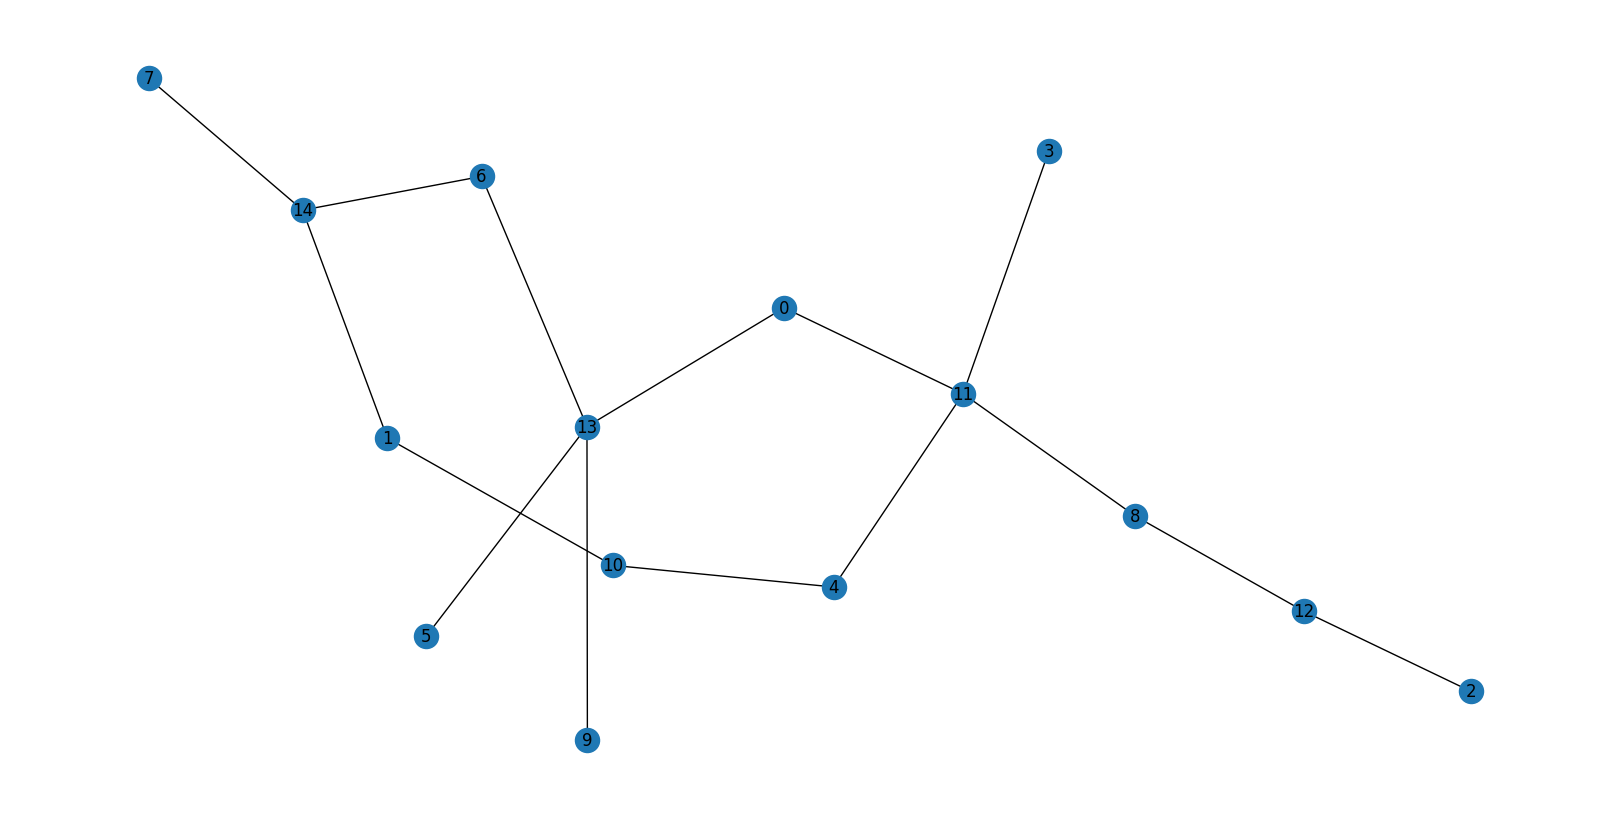

In [11]:
graph = nx.from_numpy_array(local_adjacency_matrix)

plt.figure(figsize=(16, 8))
pos = nx.kamada_kawai_layout(graph)
nx.draw(graph, pos=pos, with_labels=True)
plt.show()

### Barcode of atom 65

In [12]:
G, F = obtain_H1_barcode(adjacency_matrix=local_adjacency_matrix,
                         layers=layers,
                         mu=mu)

G = reduce_barcode(G)

In [13]:
G # there is only one ring with atoms between 0 and 4

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

The G matrix has shape $(5 \times 5)$ with a single non-zero entry at position $(0, 4)$:
$G[0,4] = 1$. This encodes **one ring** that starts at layer 0 (contains the central atom)
and first closes at layer 4.

## More examples — three different barcode types

The same material can show very different barcodes depending on the local ring structure.
We look at three more atoms to illustrate the range of topological environments:

| Atom | Element | Expected barcode | Description |
|------|---------|-----------------|-------------|
| 4570 | Si | Two bars `[0,3]` | Two rings, both passing through the centre |
| 100  | O  | Bars `[0,4]` and `[1,4]` | Two rings — one through the centre, one not |
| 5001 | Si | No bars (null barcode) | No closed rings within this LAE |

These are qualitatively different topological environments even though all atoms are in the
same silica glass sample.

### Example 2 — Silicon atom 4570 (LAE size 20)

Local atom index of centre: 18
G matrix (barcode):
[[0. 0. 0. 2.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


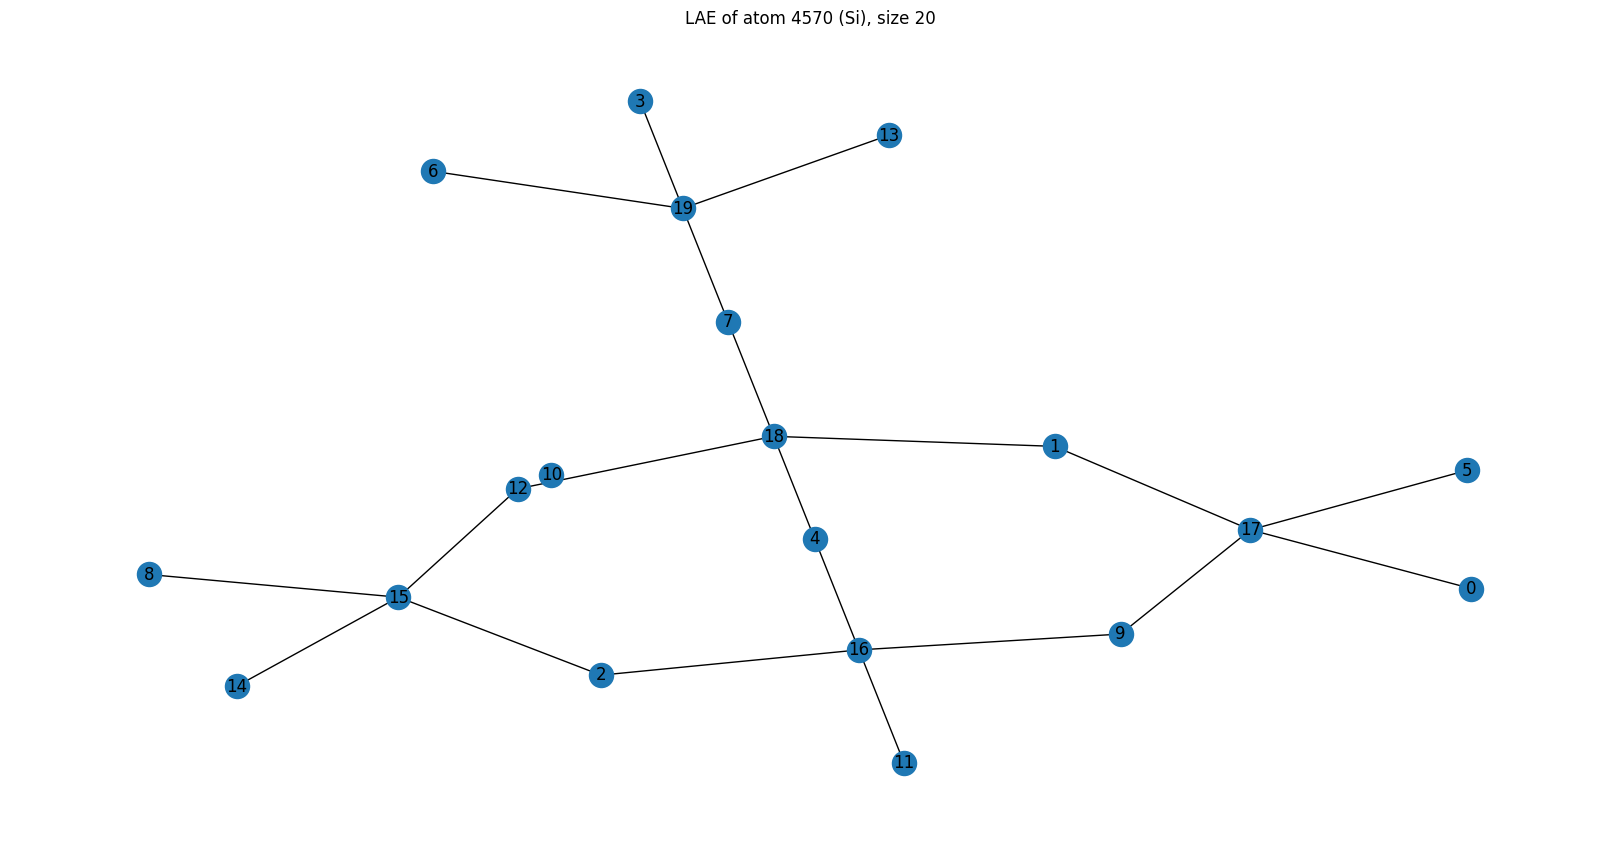

In [14]:
atom_index = 4570  # silicon
LAE_size = 20

local_adjacency_matrix, layers, local_atom_index, global_index = obtain_local_number_environment_big_structures(
    adjacency_matrix, atom_index, distances, idx_distances, LAE_size)

print(f"Local atom index of centre: {local_atom_index}")

G, F = obtain_H1_barcode(adjacency_matrix=local_adjacency_matrix, layers=layers, mu=mu)
G = reduce_barcode(G)
print("G matrix (barcode):")
print(G)

graph = nx.from_numpy_array(local_adjacency_matrix)
plt.figure(figsize=(16, 8))
pos = nx.kamada_kawai_layout(graph)
nx.draw(graph, pos=pos, with_labels=True)
plt.title(f"LAE of atom {atom_index} (Si), size {LAE_size}")
plt.show()

**Barcode:** Two bars at position $(0,3)$ — i.e., $G[0,3] = 2$.
Both rings pass through the central Si atom (layer 0) and close at layer 3. These are
**primitive rings**: their shortest path goes through the centre.

Here, algebraically independent rings = primitive rings — a coincidence specific to this atom.

### Example 3 — Oxygen atom 100 (LAE size 20)

Local atom index of centre: 0
G matrix (barcode):
[[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


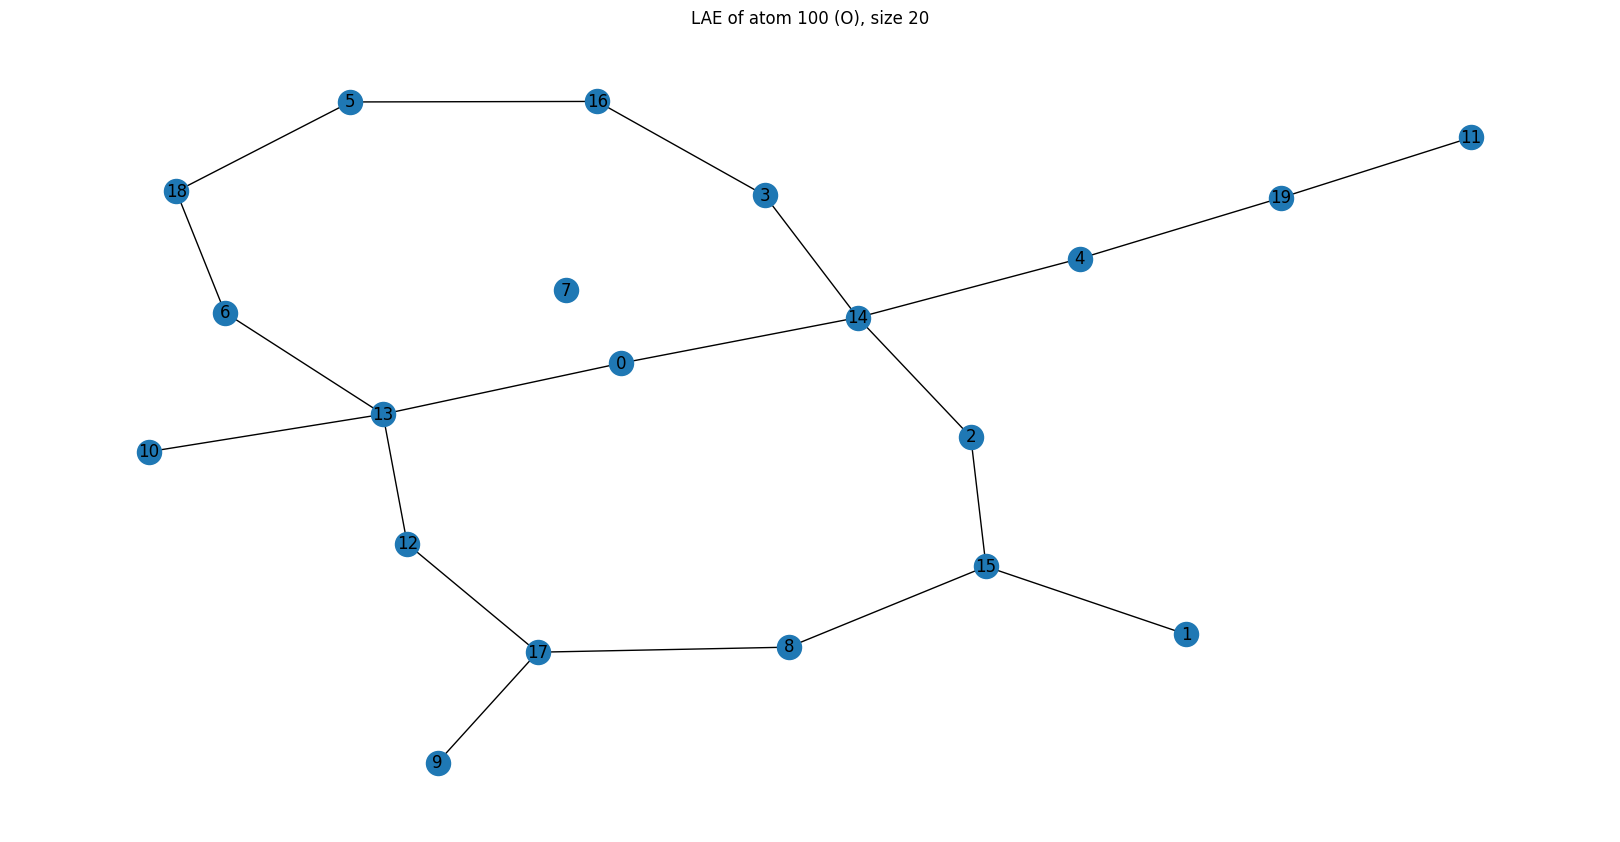

In [15]:
atom_index = 100  # oxygen
LAE_size = 20

local_adjacency_matrix, layers, local_atom_index, global_index = obtain_local_number_environment_big_structures(
    adjacency_matrix, atom_index, distances, idx_distances, LAE_size)

print(f"Local atom index of centre: {local_atom_index}")

G, F = obtain_H1_barcode(adjacency_matrix=local_adjacency_matrix, layers=layers, mu=mu)
G = reduce_barcode(G)
print("G matrix (barcode):")
print(G)

graph = nx.from_numpy_array(local_adjacency_matrix)
plt.figure(figsize=(16, 8))
pos = nx.kamada_kawai_layout(graph)
nx.draw(graph, pos=pos, with_labels=True)
plt.title(f"LAE of atom {atom_index} (O), size {LAE_size}")
plt.show()

**Barcode:** Two bars — one at $(0,4)$ and one at $(1,4)$.
- Bar $[0,4]$: a ring that **passes through the centre** (layer 0) and closes at layer 4.
- Bar $[1,4]$: a ring whose **nearest atom to the centre is in layer 1** (it does not include
  the central oxygen), and it closes at layer 4.

This is a case where algebraically independent rings ≠ primitive rings. The H₁ barcode
detects the ring that skips the centre — this is different from analysis of primitive rings, 
which would give us two primitive rings starting at the central atom and ending at layer 4.

### Example 4 — Silicon atom 5001 (LAE size 20): the null barcode

Local atom index of centre: 18
G matrix (barcode):
[[0.]]


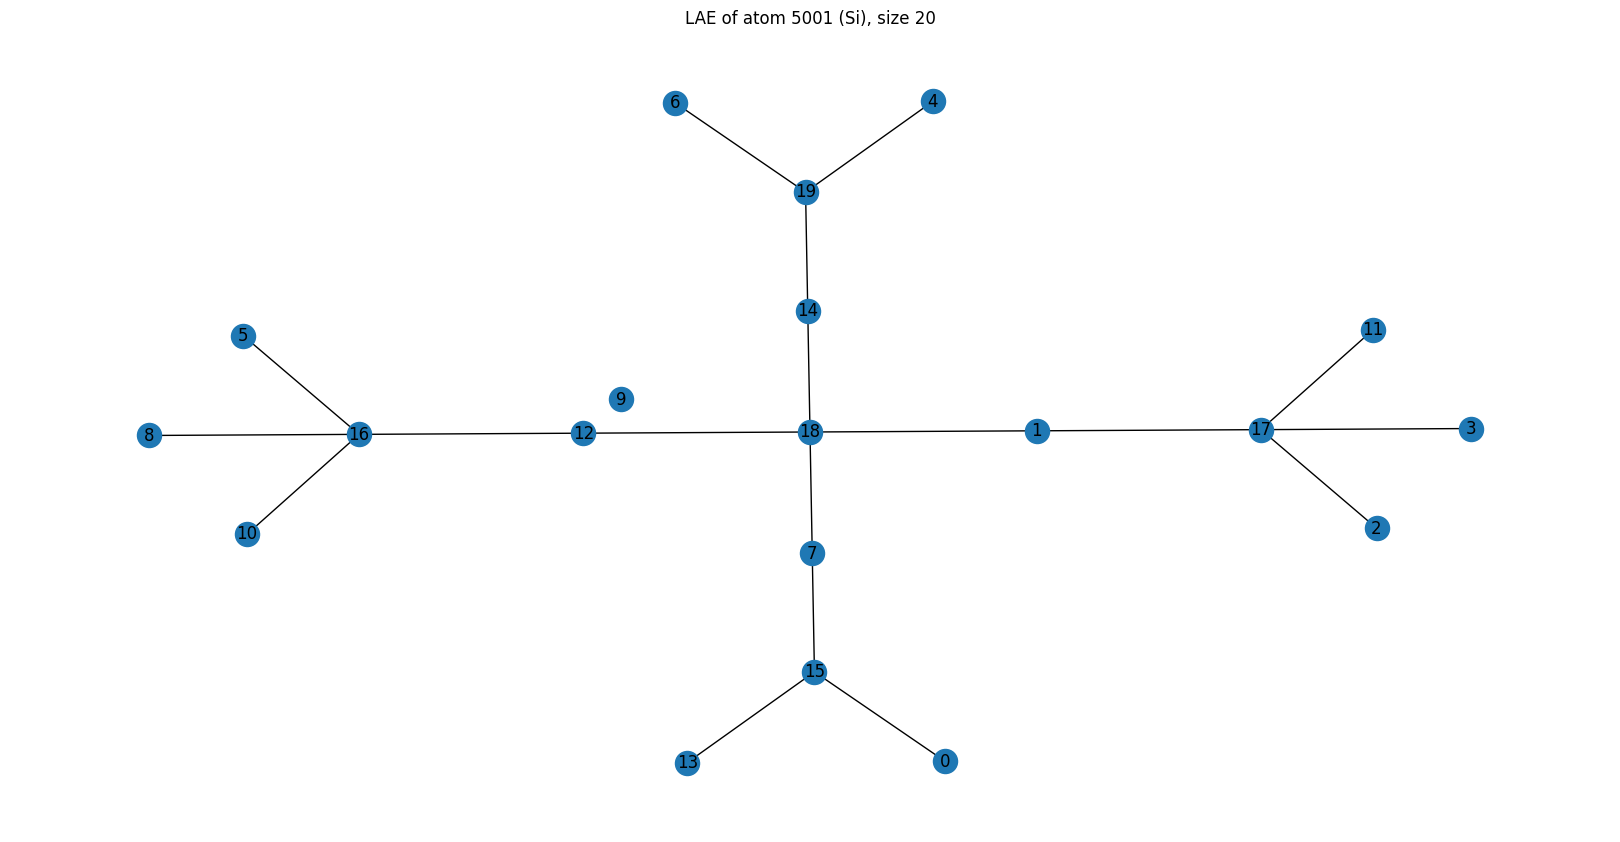

In [16]:
atom_index = 5001  # silicon
LAE_size = 20

local_adjacency_matrix, layers, local_atom_index, global_index = obtain_local_number_environment_big_structures(
    adjacency_matrix, atom_index, distances, idx_distances, LAE_size)

print(f"Local atom index of centre: {local_atom_index}")

G, F = obtain_H1_barcode(adjacency_matrix=local_adjacency_matrix, layers=layers, mu=mu)
G = reduce_barcode(G)
print("G matrix (barcode):")
print(G)

graph = nx.from_numpy_array(local_adjacency_matrix)
plt.figure(figsize=(16, 8))
pos = nx.kamada_kawai_layout(graph)
nx.draw(graph, pos=pos, with_labels=True)
plt.title(f"LAE of atom {atom_index} (Si), size {LAE_size}")
plt.show()

**Barcode:** $G = [[0]]$ — a 1×1 matrix with a single zero:
no closed rings exist within this 20-atom environment.

---

## Summary: what barcodes tell us about rings

| Barcode | Interpretation |
|---------|---------------|
| `[[0]]` | No rings|
| `G[0,d] = 1` | One ring passing through the centre, closing at layer $d$ |
| `G[c,d] = 1, c > 0` | One ring that does *not* include the central atom |
| Multiple non-zero entries | Several algebraically independent rings |

In Notebook 4 we compute the barcode for *all* 5184 atoms and summarise the distribution
with Shannon entropy metric — the Bond-Network Entropy.